# Init

In [ ]:
import torch
import numpy as np
import sympy  as sp
import plotly.graph_objects as go

# Nevergrad Imports
import nevergrad as ng

# Symxplorer Specific Imports
from   symxplorer.symbolic_exploration.domains   import ExperimentResult

from   symxplorer.designer_tools.tf_models       import Pole_Zero_TF, Second_Order_BP_TF, cascade_tf
from   symxplorer.designer_tools.visualizer      import Symbolic_Visualizer, Bode_Visualizer
# Optimizer wrapper
from   symxplorer.optimization.symbolic import Nevergrad_Symbolic_Bode_Fitter

s = sp.symbols("s")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype  = torch.double

torch.set_default_dtype(dtype)
torch.set_default_device(device)
print(f'Using device: {device} and dtype: {dtype}')

# Load the exploration result

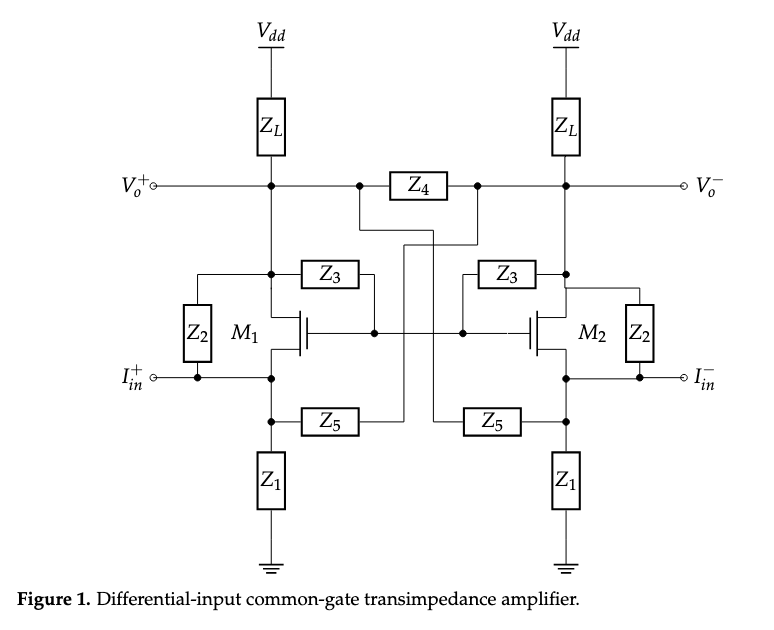

In [ ]:
experiment_name = "CG_TIA_Automated_simple"
path_to_pkl = f"Runs/{experiment_name}/results.pkl"
symbolic_experiment_result = ExperimentResult(experiment_name=experiment_name)
symbolic_experiment_result = symbolic_experiment_result.load(path_to_pkl)

# Problem Setup

## Select a topology to size

In [ ]:
ALLOWED_Z_CONNECTIONS = "Z1_Z2_ZL"
classifications, tf = symbolic_experiment_result.get_impedance_key(ALLOWED_Z_CONNECTIONS)
print(f"{ALLOWED_Z_CONNECTIONS} - count of tfs {len(classifications)}")
tf

In [ ]:
FILTER_TYPE = "BP" # should switch to using enums
classifications_filtered = symbolic_experiment_result.get_filter_types(fTypes=[FILTER_TYPE], zCombos=ALLOWED_Z_CONNECTIONS)
len(classifications_filtered)

In [ ]:
sel = 1
tf_to_size = classifications_filtered[sel]
print(f"Selected Z-combo is\n{tf_to_size.zCombo}")
print(f"numer order = {tf_to_size.tf_numer_order}\ndenom_order = {tf_to_size.tf_denom_order}\nfilter_id: {tf_to_size.filter_id}")
tf_to_size.transferFunc

### Filter Parameters

In [ ]:
print(f"filter parameters are {tf_to_size.parameters.keys()}")

In [ ]:
# Q
tf_to_size.parameters.get("Q", None)

In [ ]:
# WO
tf_to_size.parameters.get("wo", None)

In [ ]:
# bandwidth
tf_to_size.parameters.get("bandwidth", None)

In [ ]:
# K_BP
tf_to_size.parameters.get("K_BP", None)

### Symbolic Visualization

In [ ]:
sym_vis = Symbolic_Visualizer(filter_classification=tf_to_size)
sym_vis.is_defined_numerically()

In [ ]:
sym_vis.get_parameters()

In [ ]:
sym_vis.set_equal_r()

In [ ]:
sym_vis.get_parameters()

In [ ]:
sym_vis.reset_params()
sym_vis.set_params(param_str_to_value={
    "R" : 1e3, # used in case of equal R
    "C" : 1e-12, # used in case of equal C
    "R_1" : 1e3,
    "R_2" : 1e3,
    "C_L" : 100e-12,
    "L_L" : 1e-9,
    # "g_m" : 20e-3,
})
sym_vis.params_to_value

In [ ]:
magnitude_expr, phase_expr, H_numeric = sym_vis.get_bode_expression()
H_numeric

In [ ]:
sym_vis.get_filter_param()

In [ ]:
expr, val = sym_vis.eval_filter_parameter(param_name="K_BP", num_of_decimals=3)
# expr
expr.simplify()

In [ ]:
expr, val = sym_vis.eval_filter_parameter(param_name="wo", num_of_decimals=3)
# expr / (2*sp.pi)
val / (2*np.pi)

In [ ]:
sym_vis.set_params(param_str_to_value={
    "g_m" : 20e-3,
})
expr, val = sym_vis.eval_filter_parameter(param_name="K_BP", num_of_decimals=3)
expr

In [ ]:
sym_vis.print_filter_parameters()
sym_vis.visualize(start_freq_order=8.4, end_freq_order=8.8, num_of_points=200)

## Define the target TF

In [ ]:
frequencies = torch.logspace(5, 10, 20000)

fc = 1e8
q  = 1
k_bp = 1e3
target_tf_obj = Second_Order_BP_TF(q=q, fc=fc, k_bp=k_bp)
target_tf     = target_tf_obj.get_tf()
# target_tf = cascade_tf(list_of_tfs=[tf1, tf2], dc_gain_multiplier=1)

k_bp_db = 20*np.log10(k_bp)

In [ ]:
taregt_vis = Symbolic_Visualizer(tf=target_tf)
taregt_vis.visualize(start_freq_order=1, end_freq_order=10, num_of_points=200, title="Target")

In [ ]:
# Define range
lower_bound = 1e6
upper_bound = 12e6

# Generate binary mask
weighted_frequencies = torch.where((frequencies >= lower_bound) & (frequencies <= upper_bound), 1, 1)

# Optimizer

In [ ]:
print({x for x in ng.optimizers.registry})

"LogBFGSCMAPlus" optimizer has given the best result so far.

In [ ]:
ng.optimizers.registry.get("LogBFGSCMAPlus")

In [ ]:
ng_wrapper = Nevergrad_Symbolic_Bode_Fitter(
    tf_to_size=tf_to_size.transferFunc,
    target_tf=target_tf,
    c_range=[1e-12, 1e-9],
    r_range=[1e2, 1e5],
    frequencies=frequencies,
    # freq_weights=weighted_frequencies,
    max_loss=float('inf'),
    loss_norm_method='min-max',
    loss_type="mse",
    optimizer_name="LogBFGSCMAPlus",
    random_seed=42
)

In [ ]:
ng_wrapper.parameterize(log_scale=False)

In [ ]:
ng_wrapper.create_experiment(budget=5000)
ng_wrapper.optimize(include_mag_loss=False, include_phase_loss=True, render_optimization_trace=True)

Optimizing:  12%|█▏        | 588/5000 [00:15<01:37, 45.22trial/s]/Users/danialnoorizadeh/.pyenv/versions/myenv/lib/python3.12/site-packages/cma/evolution_strategy.py:2420: InjectionWarning:

orphanated injected solution {'iteration': 37, 'index': 0, 'counter': 1}
                            This could be a bug in the calling order/logics or due to
                            a too small popsize used in `ask()` or when only using
                            `ask(1)` repeatedly. Please check carefully.
                            In case this is desired, the warning can be surpressed with
                            ``warnings.simplefilter("ignore", cma.evolution_strategy.InjectionWarning)``
                            

Optimizing:  12%|█▏        | 609/5000 [00:15<01:36, 45.72trial/s]

In [ ]:
best_params, loss = ng_wrapper.get_best()
best_params, loss

In [ ]:
ng_wrapper.plot_solution(best_params)

## Plot

In [ ]:
# best_params, loss = ng_wrapper.optimizer_trace[4200]
# best_params = ng_wrapper.denormalize_params(best_params.value)
# best_params, loss

In [ ]:
ng_wrapper.plot_solution(best_params)